# Policy Lever Impact Analysis

This notebook evaluates how key policy levers affect permitting outcomes.

Levers included:
- Staffing levels (planning, public works, fire)
- Permit volume (`num_permits`)
- Process layout (`sequential` / `standard` / `parallel`) and AI review mode where applicable

Pre-application timeline distribution is fixed at **lognormal_180** for this notebook.

For each scenario, the notebook runs multiple Monte Carlo repetitions and summarizes impacts on:
- Mean total processing time
- Median total processing time
- Completion count
- Mean staff utilization (planning, public works, fire)


In [25]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from run_simulation import run_multiple_simulations, plot_staff_utilization_series

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


In [ ]:
# --- Baseline + policy scenario grid ---
BASE_PARAMS = {
    "name": "baseline",
    "sequential": "standard",
    "ai_review": "none",
    "permit_mix": "all_custom_non_like_for_like",
    "pre_application_distribution": "baseline",
    "review_duration_families": None,
    "review_duration_multipliers": None,
    "planning_staff_count": 20,
    "planning_caseload_per_staff": 7,
    "public_works_staff_count": 30,
    "public_works_caseload_per_staff": 7,
    "fire_staff_count": 10,
    "fire_caseload_per_staff": 7,
}

N_RUNS = 100
BASE_SEED = 42
SIMULATION_DURATION = None

NUM_PERMITS_OPTIONS = [2000, 6500]

# Scenario dimensions (not policy levers)
STAFFING_SCENARIOS = {
    "low": {"planning_staff_count": 2, "public_works_staff_count": 3, "fire_staff_count": 1},
    "medium": {"planning_staff_count": 8, "public_works_staff_count": 12, "fire_staff_count": 4},
    "high": {"planning_staff_count": 20, "public_works_staff_count": 30, "fire_staff_count": 10},
}
PRE_APPLICATION_DISTRIBUTIONS = ["lognormal_180"]
# Homogeneous heavy-tailed mix vs balanced segment distribution (see permit_simulation.PERMIT_MIX_PRESETS).
# Balanced mix is not crossed with seq/parallel/AI levers below → 2×3×1×5 + 2×3×1×1 = 30 + 6 = 36 scenarios.
PERMIT_MIX_OPTIONS = ["all_custom_non_like_for_like", "balanced"]

# Policy levers
SEQUENTIAL_OPTIONS = ["sequential", "standard", "parallel"]
AI_REVIEW_OPTIONS = ["none", "initial_check", "full_review"]

# AI review variants are only modeled under the standard process layout.
EXCLUDED_SEQUENTIAL_AI_COMBOS = frozenset(
    {
        ("sequential", "initial_check"),
        ("sequential", "full_review"),
        ("parallel", "initial_check"),
        ("parallel", "full_review"),
    }
)


def build_scenarios():
    scenarios = []
    for (
        num_permits,
        (staffing_name, staffing),
        pre_app_dist,
        sequential_mode,
        ai_mode,
        permit_mix,
    ) in itertools.product(
        NUM_PERMITS_OPTIONS,
        STAFFING_SCENARIOS.items(),
        PRE_APPLICATION_DISTRIBUTIONS,
        SEQUENTIAL_OPTIONS,
        AI_REVIEW_OPTIONS,
        PERMIT_MIX_OPTIONS,
    ):
        if (sequential_mode, ai_mode) in EXCLUDED_SEQUENTIAL_AI_COMBOS:
            continue
        # Balanced permit mix only under baseline process (standard + no AI)—do not
        # cross it with sequential, parallel, or AI review modes.
        if permit_mix == "balanced" and (
            sequential_mode != "standard" or ai_mode != "none"
        ):
            continue
        scenario = dict(BASE_PARAMS)
        scenario["permit_mix"] = permit_mix
        scenario["name"] = (
            f"permits={num_permits}|staffing={staffing_name}|"
            f"preapp={pre_app_dist}|seq={sequential_mode}|ai={ai_mode}|mix={permit_mix}"
        )
        scenario["planning_staff_count"] = staffing["planning_staff_count"]
        scenario["public_works_staff_count"] = staffing["public_works_staff_count"]
        scenario["fire_staff_count"] = staffing["fire_staff_count"]
        scenario["pre_application_distribution"] = pre_app_dist
        scenario["sequential"] = sequential_mode
        scenario["ai_review"] = ai_mode
        scenarios.append((num_permits, staffing_name, pre_app_dist, sequential_mode, ai_mode, scenario))
    return scenarios


SCENARIOS = build_scenarios()
n_hom = sum(1 for *_, s in SCENARIOS if s["permit_mix"] == "all_custom_non_like_for_like")
n_bal = sum(1 for *_, s in SCENARIOS if s["permit_mix"] == "balanced")
print(f"Total scenarios: {len(SCENARIOS)} ({n_hom} homogeneous-mix grid + {n_bal} balanced-mix at baseline policy only)")
print("Staffing scenarios:", list(STAFFING_SCENARIOS.keys()))
print("Pre-application distributions:", PRE_APPLICATION_DISTRIBUTIONS)
print("Permit mix presets:", PERMIT_MIX_OPTIONS)
print("Policy levers:")
print("  sequential:", SEQUENTIAL_OPTIONS)
print("  ai_review:", AI_REVIEW_OPTIONS)
print("  excluded seq×ai combinations:", sorted(EXCLUDED_SEQUENTIAL_AI_COMBOS))


Total scenarios: 36 (30 homogeneous-mix grid + 6 balanced-mix at baseline policy only)
Staffing scenarios: ['low', 'medium', 'high']
Pre-application distributions: ['lognormal_180']
Permit mix presets: ['all_custom_non_like_for_like', 'balanced']
Policy levers:
  sequential: ['sequential', 'standard', 'parallel']
  ai_review: ['none', 'initial_check', 'full_review']
  excluded seq×ai combinations: [('parallel', 'full_review'), ('parallel', 'initial_check'), ('sequential', 'full_review'), ('sequential', 'initial_check')]


In [27]:
# --- Run experiments ---
rows = []
per_run_rows = []
util_by_scenario = {}

for idx, (num_permits, staffing_name, pre_app_dist, sequential_mode, ai_mode, scenario) in enumerate(SCENARIOS, start=1):
    results, avg_util_by_scenario = run_multiple_simulations(
        n_runs=N_RUNS,
        num_permits=num_permits,
        simulation_duration=SIMULATION_DURATION,
        base_seed=BASE_SEED,
        scenario_params_list=[scenario],
        collect_permits=True,
        collect_average_staff_utilization=True,
        utilization_kind="implied",
        utilization_step=0.1,
    )

    util = avg_util_by_scenario[scenario["name"]]
    util_by_scenario[scenario["name"]] = util

    app_to_ready_mean_by_run = []
    app_to_ready_median_by_run = []
    app_to_ready_std_by_run = []
    completed_by_run = []

    for run_index, r in enumerate(results):
        permits = r.get("permits", [])
        durations = [
            (p.ready_for_construction - p.planning_request)
            for p in permits
            if p.ready_for_construction is not None and p.planning_request is not None
        ]
        if durations:
            arr = np.asarray(durations, dtype=float)
            run_mean = float(np.mean(arr))
            run_median = float(np.median(arr))
            run_std = float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0

            q1 = float(np.percentile(arr, 25))
            q3 = float(np.percentile(arr, 75))
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            whislo = float(arr[arr >= lower_bound].min())
            whishi = float(arr[arr <= upper_bound].max())

            app_to_ready_mean_by_run.append(run_mean)
            app_to_ready_median_by_run.append(run_median)
            app_to_ready_std_by_run.append(run_std)
        else:
            run_mean = run_median = run_std = np.nan
            q1 = q3 = whislo = whishi = np.nan
            app_to_ready_mean_by_run.append(np.nan)
            app_to_ready_median_by_run.append(np.nan)
            app_to_ready_std_by_run.append(np.nan)

        completed_by_run.append(len(durations))
        per_run_rows.append(
            {
                "scenario": scenario["name"],
                "run_index": run_index,
                "num_permits": num_permits,
                "staffing_scenario": staffing_name,
                "pre_application_distribution": pre_app_dist,
                "sequential": sequential_mode,
                "ai_review": ai_mode,
                "permit_mix": scenario["permit_mix"],
                "application_to_ready_run_mean_days": run_mean,
                "application_to_ready_run_median_days": run_median,
                "application_to_ready_run_std_days": run_std,
                "application_to_ready_run_q1_days": q1,
                "application_to_ready_run_q3_days": q3,
                "application_to_ready_run_whislo_days": whislo,
                "application_to_ready_run_whishi_days": whishi,
            }
        )

    rows.append(
        {
            "scenario": scenario["name"],
            "num_permits": num_permits,
            "staffing_scenario": staffing_name,
            "pre_application_distribution": pre_app_dist,
            "sequential": sequential_mode,
            "ai_review": ai_mode,
            "permit_mix": scenario["permit_mix"],
            "planning_staff_count": scenario["planning_staff_count"],
            "public_works_staff_count": scenario["public_works_staff_count"],
            "fire_staff_count": scenario["fire_staff_count"],
            "application_to_ready_mean_days": float(np.nanmean(app_to_ready_mean_by_run)),
            "application_to_ready_mean_days_std": float(np.nanstd(app_to_ready_mean_by_run, ddof=1) if len(app_to_ready_mean_by_run) > 1 else 0.0),
            "application_to_ready_median_days": float(np.nanmean(app_to_ready_median_by_run)),
            "application_to_ready_std_within_run_mean_days": float(np.nanmean(app_to_ready_std_by_run)),
            "completed_mean": float(np.mean(completed_by_run)),
            "planning_util_mean_pct": float(100.0 * np.mean(util["planning"])),
            "planning_util_peak_pct": float(100.0 * np.max(util["planning"])),
            "public_works_util_mean_pct": float(100.0 * np.mean(util["public_works"])),
            "public_works_util_peak_pct": float(100.0 * np.max(util["public_works"])),
            "fire_util_mean_pct": float(100.0 * np.mean(util["fire"])),
            "fire_util_peak_pct": float(100.0 * np.max(util["fire"])),
        }
    )

    if idx % 10 == 0 or idx == len(SCENARIOS):
        print(f"Completed {idx}/{len(SCENARIOS)} scenarios")

impact_df = pd.DataFrame(rows)
impact_df.head()



Completed 10/36 scenarios
Completed 20/36 scenarios
Completed 30/36 scenarios
Completed 36/36 scenarios


,scenario,num_permits,staffing_scenario,pre_application_distribution,sequential,ai_review,permit_mix,planning_staff_count,public_works_staff_count,fire_staff_count,application_to_ready_mean_days,application_to_ready_mean_days_std,application_to_ready_median_days,application_to_ready_std_within_run_mean_days,completed_mean,planning_util_mean_pct,planning_util_peak_pct,public_works_util_mean_pct,public_works_util_peak_pct,fire_util_mean_pct,fire_util_peak_pct
0,permits=2000|staffing=low|preapp=lognormal_180...,2000,low,lognormal_180,sequential,none,all_custom_non_like_for_like,2,3,1,761.073294,7.765729,806.668005,396.392239,2000.0,1599.379725,9490.142857,17.221963,64.000000,23.502636,95.857143
1,permits=2000|staffing=low|preapp=lognormal_180...,2000,low,lognormal_180,standard,none,all_custom_non_like_for_like,2,3,1,761.615389,7.402368,807.952713,403.272407,2000.0,1693.303015,9856.714286,17.192355,64.190476,23.484670,99.857143
2,permits=2000|staffing=low|preapp=lognormal_180...,2000,low,lognormal_180,standard,none,balanced,2,3,1,473.252699,8.693590,516.209563,264.185690,2000.0,1012.881042,8500.785714,10.528004,60.904762,128.401929,798.428571
3,permits=2000|staffing=low|preapp=lognormal_180...,2000,low,lognormal_180,standard,initial_check,all_custom_non_like_for_like,2,3,1,552.393689,5.461496,593.588953,284.552370,2000.0,1100.282044,8672.571429,12.624268,64.380952,17.993286,103.571429
4,permits=2000|staffing=low|preapp=lognormal_180...,2000,low,lognormal_180,standard,full_review,all_custom_non_like_for_like,2,3,1,163.715937,1.511649,153.431941,63.138582,2000.0,2.880974,74.357143,1.714973,36.809524,2.113232,49.142857


In [28]:
# --- Policy lever impacts (parallel vs sequential, AI initial vs full) ---
def effect_span(df, lever, metric):
    grouped = df.groupby(lever, as_index=False)[metric].mean().sort_values(lever)
    return grouped, grouped[metric].max() - grouped[metric].min()


# Policy-lever tables compare process/AI choices holding the homogeneous permit mix fixed.
impact_df_policy = (
    impact_df.loc[impact_df["permit_mix"].eq("all_custom_non_like_for_like")]
    if "permit_mix" in impact_df.columns
    else impact_df
)

metrics = [
    "application_to_ready_mean_days",
    "application_to_ready_median_days",
    "planning_util_mean_pct",
    "public_works_util_mean_pct",
    "fire_util_mean_pct",
]

policy_levers = ["sequential", "ai_review"]

for metric in metrics:
    print("\n" + "=" * 90)
    print(f"Metric: {metric}")
    print("=" * 90)
    spans = []
    for lever in policy_levers:
        grouped, span = effect_span(impact_df_policy, lever, metric)
        spans.append((lever, span))
        print(f"\nPolicy lever: {lever} (span={span:.2f})")
        display(grouped)

    print("\nPolicy lever rank by effect span:")
    for lever, span in sorted(spans, key=lambda x: x[1], reverse=True):
        print(f"  {lever:24s} {span:10.2f}")

print("\n" + "=" * 90)
print("Policy levers within each staffing / permit / pre-app scenario")
print("=" * 90)
strata_cols = ["num_permits", "staffing_scenario", "pre_application_distribution"]
for keys, group in impact_df_policy.groupby(strata_cols):
    print(f"\nStratum: permits={keys[0]}, staffing={keys[1]}, pre_app={keys[2]}")
    pivot = group.pivot_table(
        index="sequential",
        columns="ai_review",
        values="application_to_ready_mean_days",
        aggfunc="mean",
    )
    display(pivot)



Metric: application_to_ready_mean_days

Policy lever: sequential (span=244.27)


,sequential,application_to_ready_mean_days
0,parallel,713.960898
1,sequential,750.528985
2,standard,506.263877



Policy lever: ai_review (span=563.18)


,ai_review,application_to_ready_mean_days
0,full_review,178.720624
1,initial_check,578.859740
2,none,741.900384



Policy lever rank by effect span:
  ai_review                    563.18
  sequential                   244.27

Metric: application_to_ready_median_days

Policy lever: sequential (span=255.37)


...

ai_review,full_review,initial_check,none
sequential,,,
parallel,NaN,NaN,202.836564
sequential,NaN,NaN,315.242169
standard,165.520737,231.735212,311.460328



Stratum: permits=6500, staffing=low, pre_app=lognormal_180


ai_review,full_review,initial_check,none
sequential,,,
parallel,NaN,NaN,2505.692759
sequential,NaN,NaN,2284.761929
standard,250.063043,1821.769445,2387.147974



Stratum: permits=6500, staffing=medium, pre_app=lognormal_180


ai_review,full_review,initial_check,none
sequential,,,
parallel,NaN,NaN,640.930718
sequential,NaN,NaN,682.944696
standard,165.559657,508.67699,697.692041


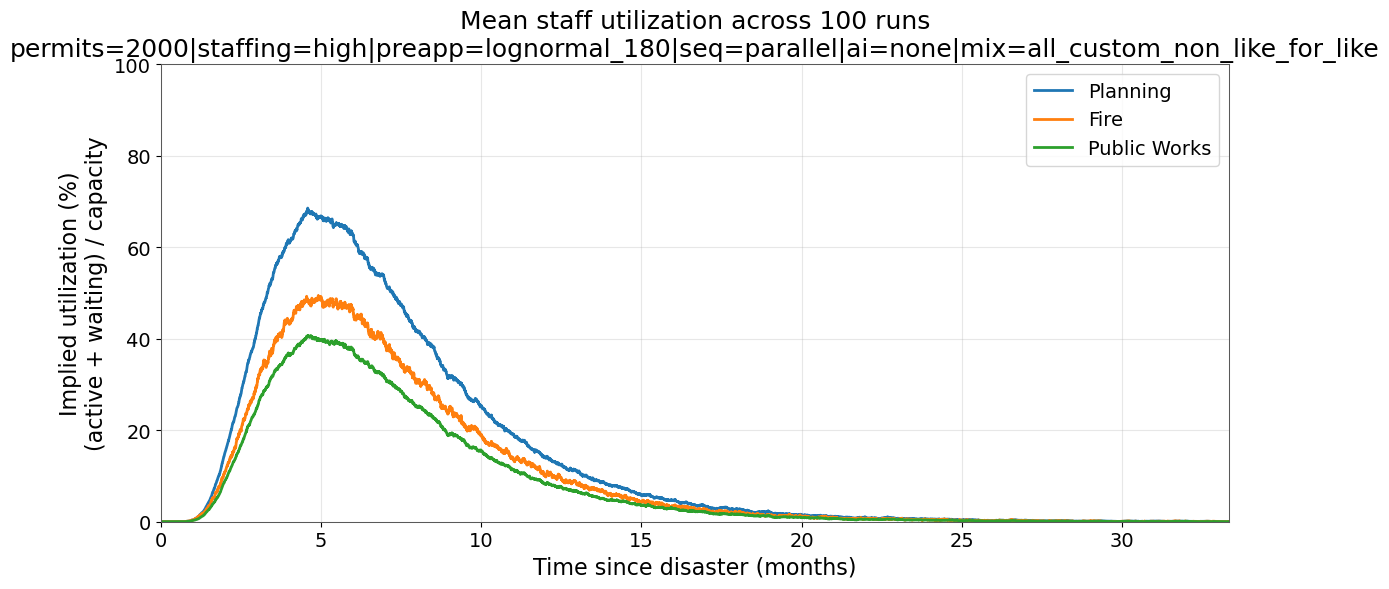

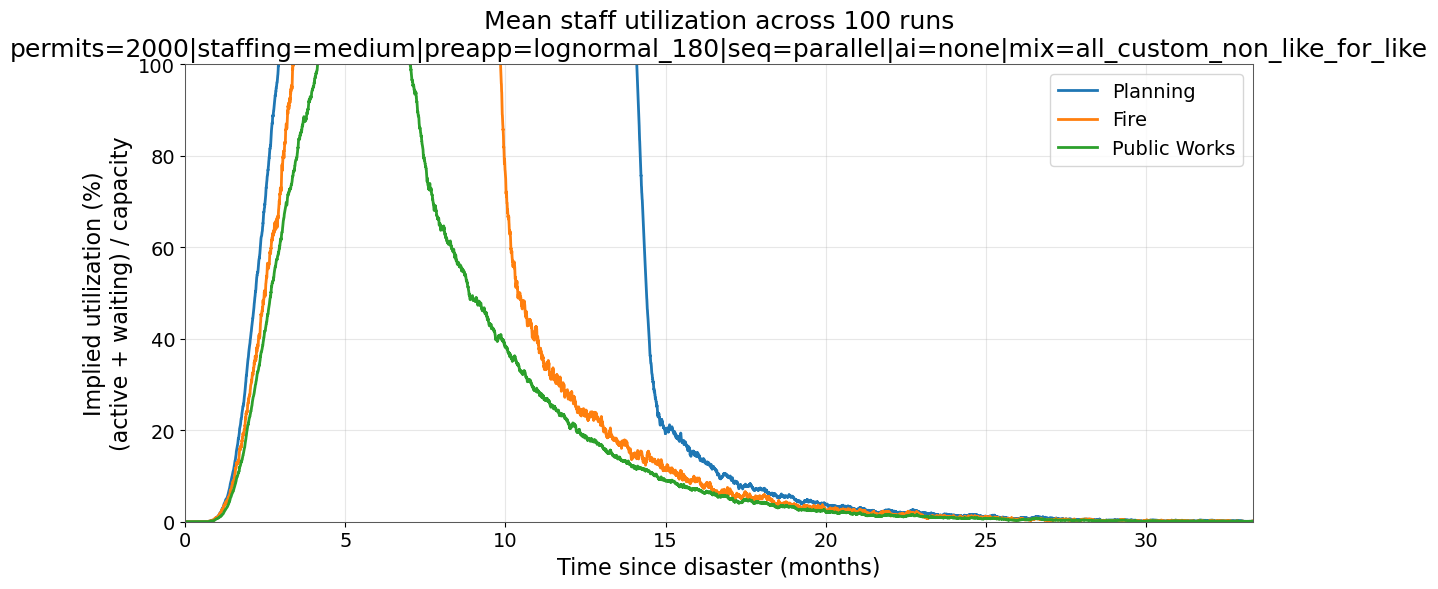

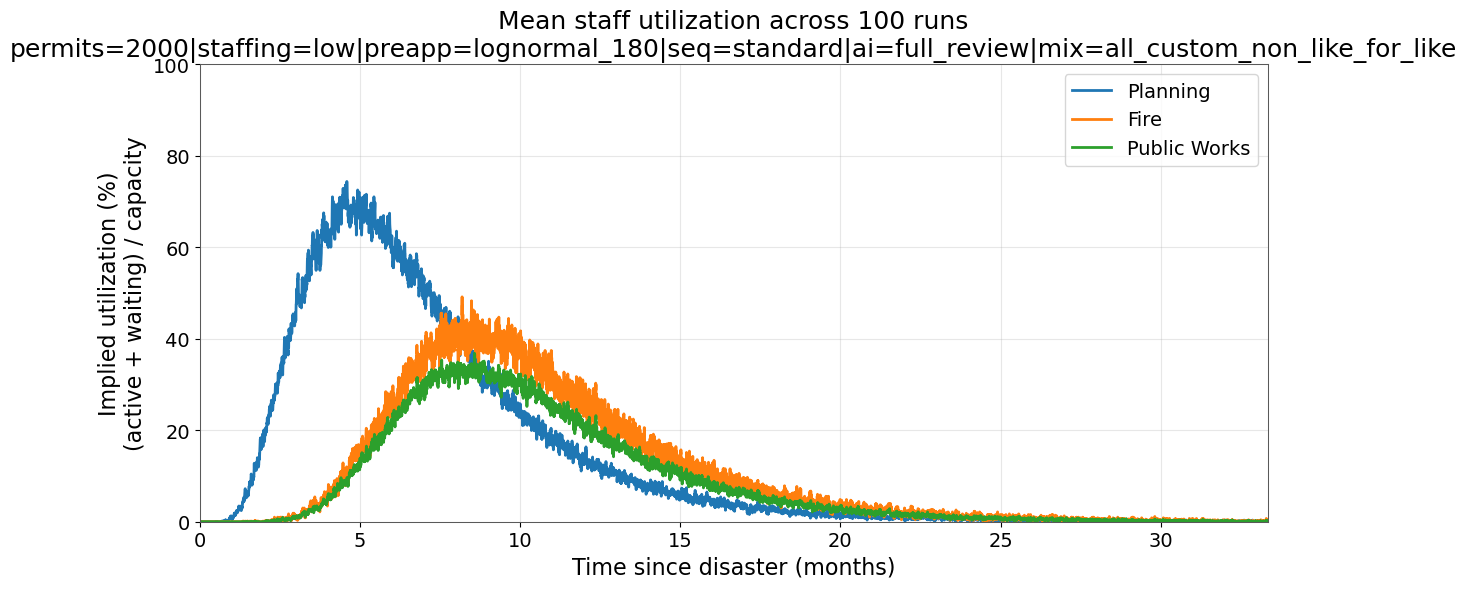

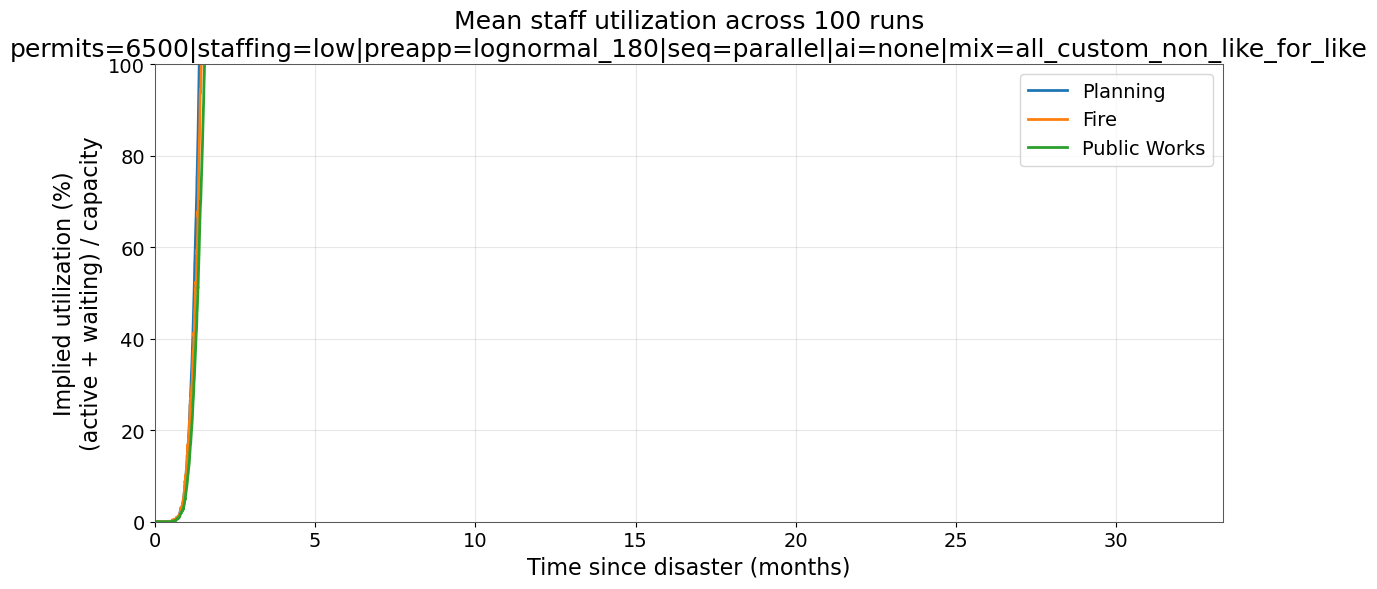

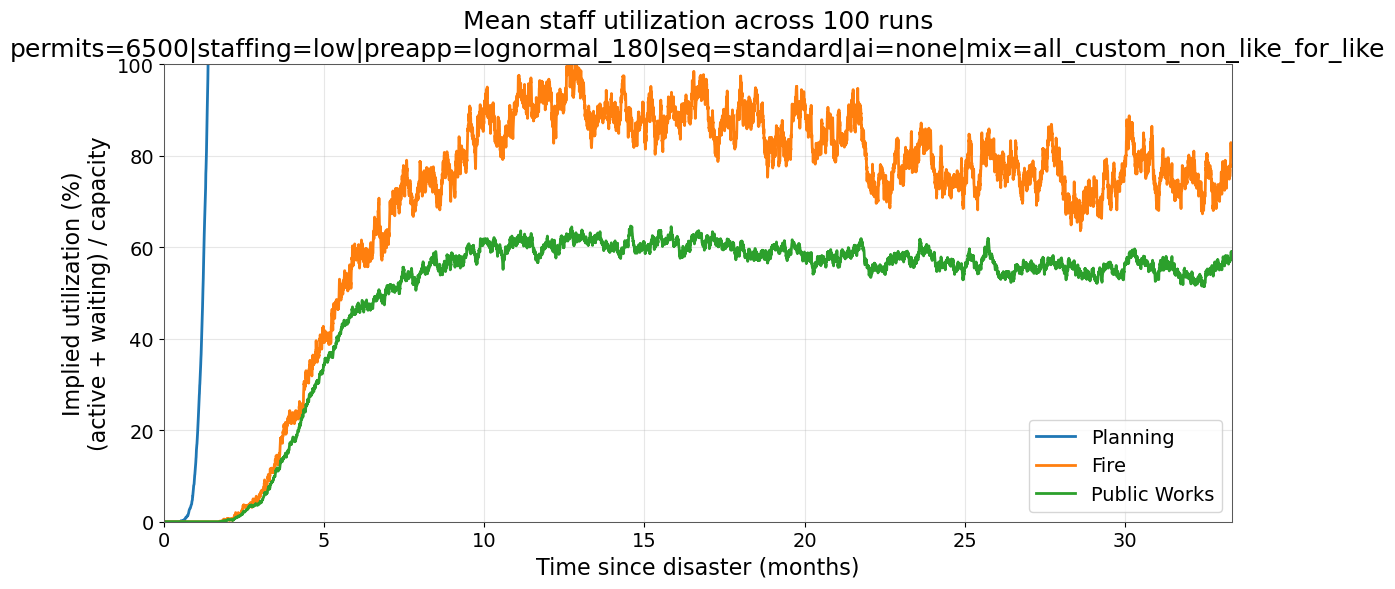

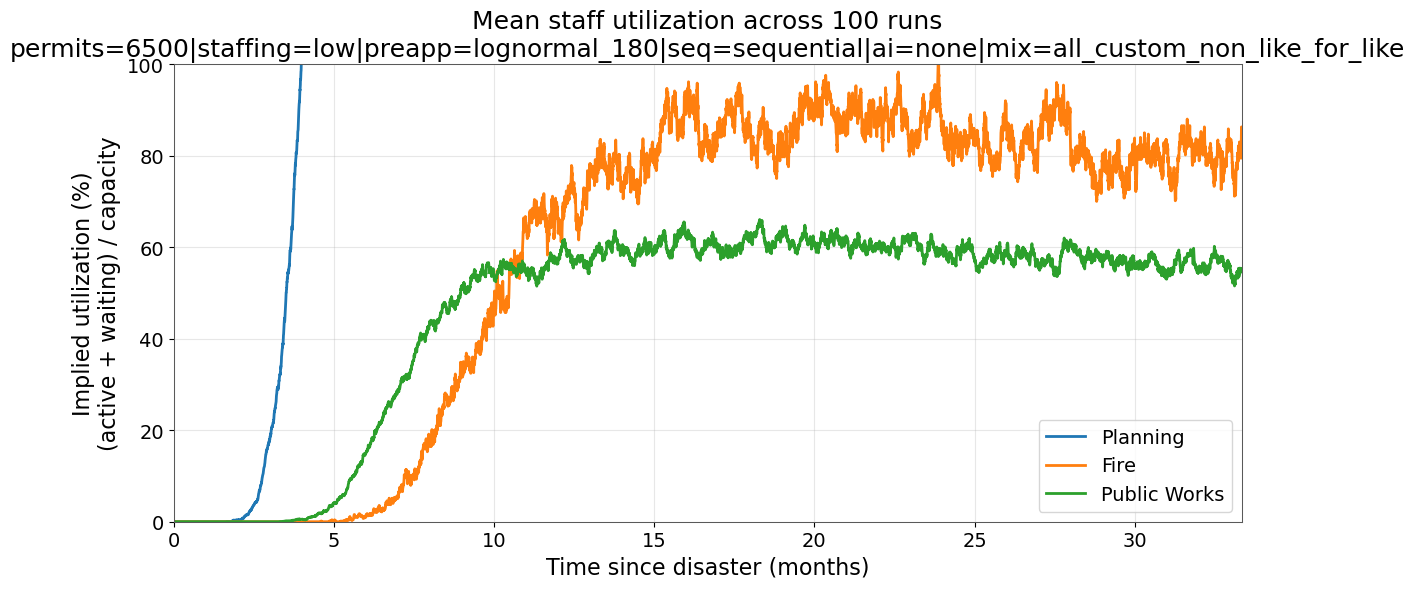

In [29]:
# --- Plot average utilization for selected scenarios ---
# Pick a few scenarios to compare; adjust list as needed.
impact_df_policy = (
    impact_df.loc[impact_df["permit_mix"].eq("all_custom_non_like_for_like")]
    if "permit_mix" in impact_df.columns
    else impact_df
)
selected = impact_df_policy.sort_values("application_to_ready_mean_days").head(3)["scenario"].tolist()
selected += impact_df_policy.sort_values("application_to_ready_mean_days", ascending=False).head(3)["scenario"].tolist()
selected = list(dict.fromkeys(selected))

for scenario_name in selected:
    util = util_by_scenario[scenario_name]
    plot_staff_utilization_series(
        util,
        as_percent=True,
        title=f"Mean staff utilization across {util['n_runs']} runs\n{scenario_name}",
        xlim=(0, min(1000, util["max_day"])),
        ylim=(0, 100),
    )


In [30]:
# --- Save results for reuse ---
from pathlib import Path

results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

output_path = results_dir / "policy_lever_impact_results.csv"
impact_df.to_csv(output_path, index=False)
print(f"Saved: {output_path}")

impact_df_policy = (
    impact_df.loc[impact_df["permit_mix"].eq("all_custom_non_like_for_like")]
    if "permit_mix" in impact_df.columns
    else impact_df
)

# Stratum = staffing / permit volume / pre-application distribution.
# Within each stratum and each lever value (process layout or AI setting), pool across
# configurations of the *other* lever: report the mean of MC-averaged mean, median,
# and permit-level dispersion (average within-run sample std across runs).

strata_cols = ["num_permits", "staffing_scenario", "pre_application_distribution"]
intervention_rows = []
for keys, grp in impact_df_policy.groupby(strata_cols, sort=False):
    base = dict(zip(strata_cols, keys))
    for lever_col in ("sequential", "ai_review"):
        for val, sub in grp.groupby(lever_col, sort=False):
            intervention_rows.append(
                {
                    **base,
                    "intervention_lever": lever_col,
                    "intervention_value": val,
                    "avg_mean_application_to_ready_days": float(sub["application_to_ready_mean_days"].mean()),
                    "avg_median_application_to_ready_days": float(
                        sub["application_to_ready_median_days"].mean()
                    ),
                    "avg_std_application_to_ready_days": float(
                        sub["application_to_ready_std_within_run_mean_days"].mean()
                    ),
                }
            )

intervention_path = results_dir / "policy_lever_application_to_ready_by_intervention.csv"
pd.DataFrame(intervention_rows).to_csv(intervention_path, index=False)
print(f"Saved: {intervention_path}")

per_run_path = results_dir / "policy_lever_impact_per_run.csv"
pd.DataFrame(per_run_rows).to_csv(per_run_path, index=False)
print(f"Saved: {per_run_path}")


Saved: results/policy_lever_impact_results.csv
Saved: results/policy_lever_application_to_ready_by_intervention.csv
Saved: results/policy_lever_impact_per_run.csv


### Figures: comparisons by cohort size and staffing

Loads `results/policy_lever_impact_per_run.csv` (one row per Monte Carlo run per scenario; produced when you run the experiments and save cells) and builds **box-and-whisker** figures.

For each permit volume, the figure has **three rows** (run-level **mean**, **median**, and **standard deviation** across permits for application-to-ready days in each run) and **three columns** (low / medium / high staffing).

Simulations use the **lognormal_180** pre-application timeline only. Along the x-axis, **five** side-by-side boxes correspond to policies in this order: baseline (standard / no AI), initial AI review, full AI review, sequential, parallel.

Figures are written under `results/`.

Saved: results/policy_intervention_comparison_graph_table.csv


,num_permits,staffing_scenario,pre_application_distribution,permit_mix,scenario_label,sequential,ai_review,box_q1_days,box_median_days,box_q3_days,whisker_low_days,whisker_high_days
0,2000,low,lognormal_180,all_custom_non_like_for_like,Baseline,standard,none,391.996944,807.952713,1128.246779,57.058693,1619.306132
1,2000,low,lognormal_180,all_custom_non_like_for_like,Initial AI review,standard,initial_check,255.852840,593.588953,809.832234,50.943709,1239.418732
2,2000,low,lognormal_180,all_custom_non_like_for_like,Full AI review,standard,full_review,120.913302,153.431941,194.518573,34.055422,304.095177
3,2000,low,lognormal_180,all_custom_non_like_for_like,Sequential,sequential,none,365.519855,806.668005,1120.701416,67.296978,1624.298451
4,2000,low,lognormal_180,all_custom_non_like_for_like,Parallel,parallel,none,496.403037,698.935277,1007.668081,32.614037,1299.861669
5,2000,low,lognormal_180,balanced,Expedited permit options,standard,none,190.420458,516.209563,715.052468,17.909722,1092.230562
6,2000,medium,lognormal_180,all_custom_non_like_for_like,Baseline,standard,none,154.032573,202.067693,294.108107,48.284412,502.265721
7,2000,medium,lognormal_180,all_custom_non_like_for_like,Initial AI review,standard,initial_check,135.955322,171.973009,219.745565,43.447232,344.376998
8,2000,medium,lognormal_180,all_custom_non_like_for_like,Full AI review,standard,full_review,120.767889,153.335818,194.578455,35.045419,304.227116
9,2000,medium,lognormal_180,all_custom_non_like_for_like,Sequential,sequential,none,178.715457,228.859409,302.943321,56.254560,487.730663


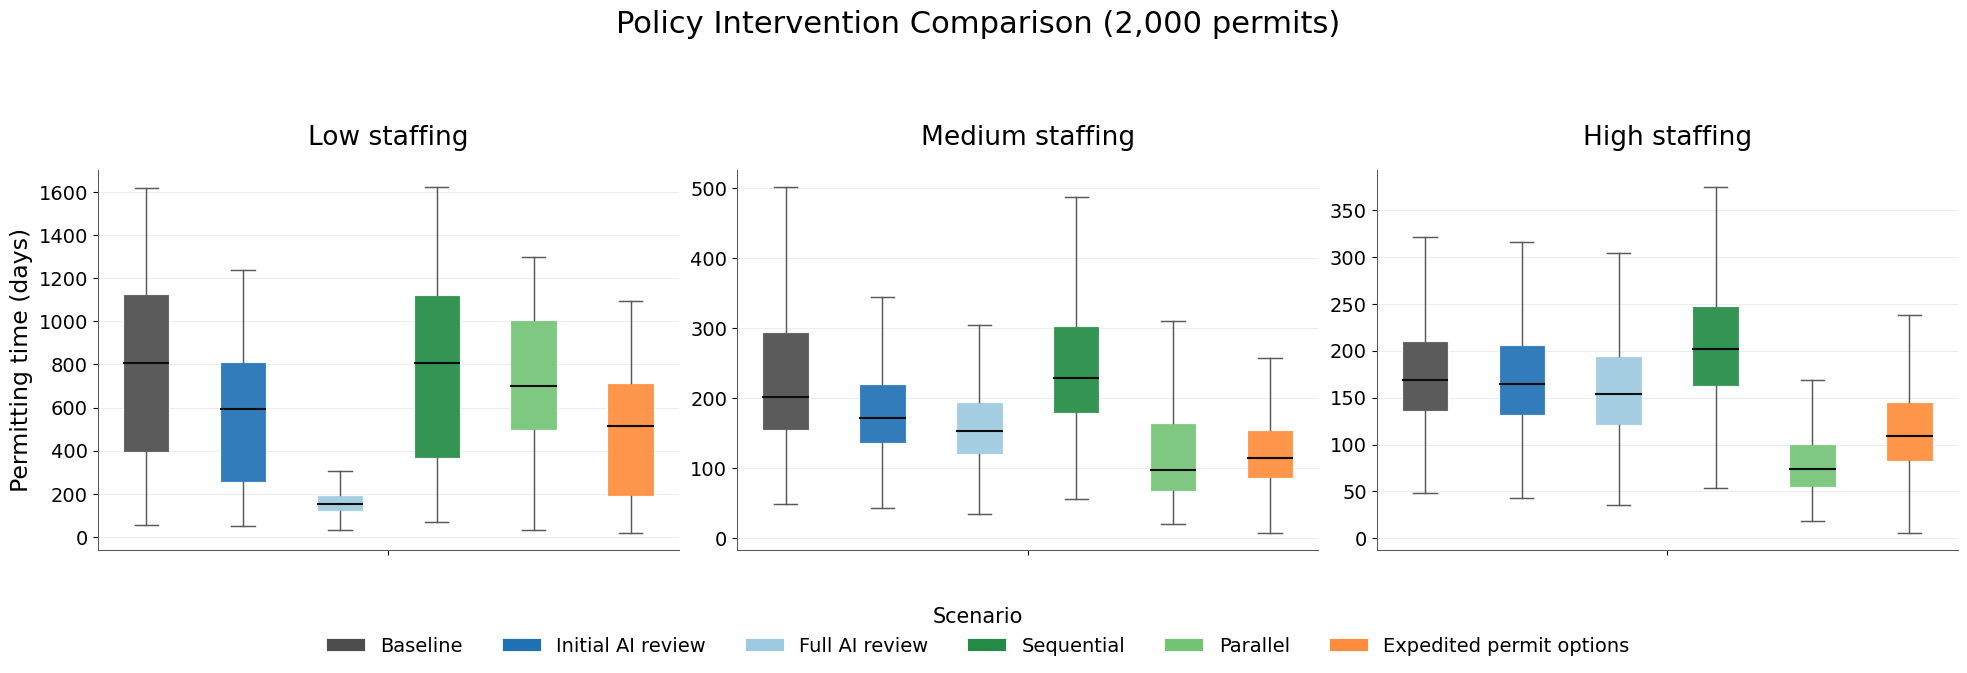

results/app_to_ready_policy_comparison_2000_permits.png


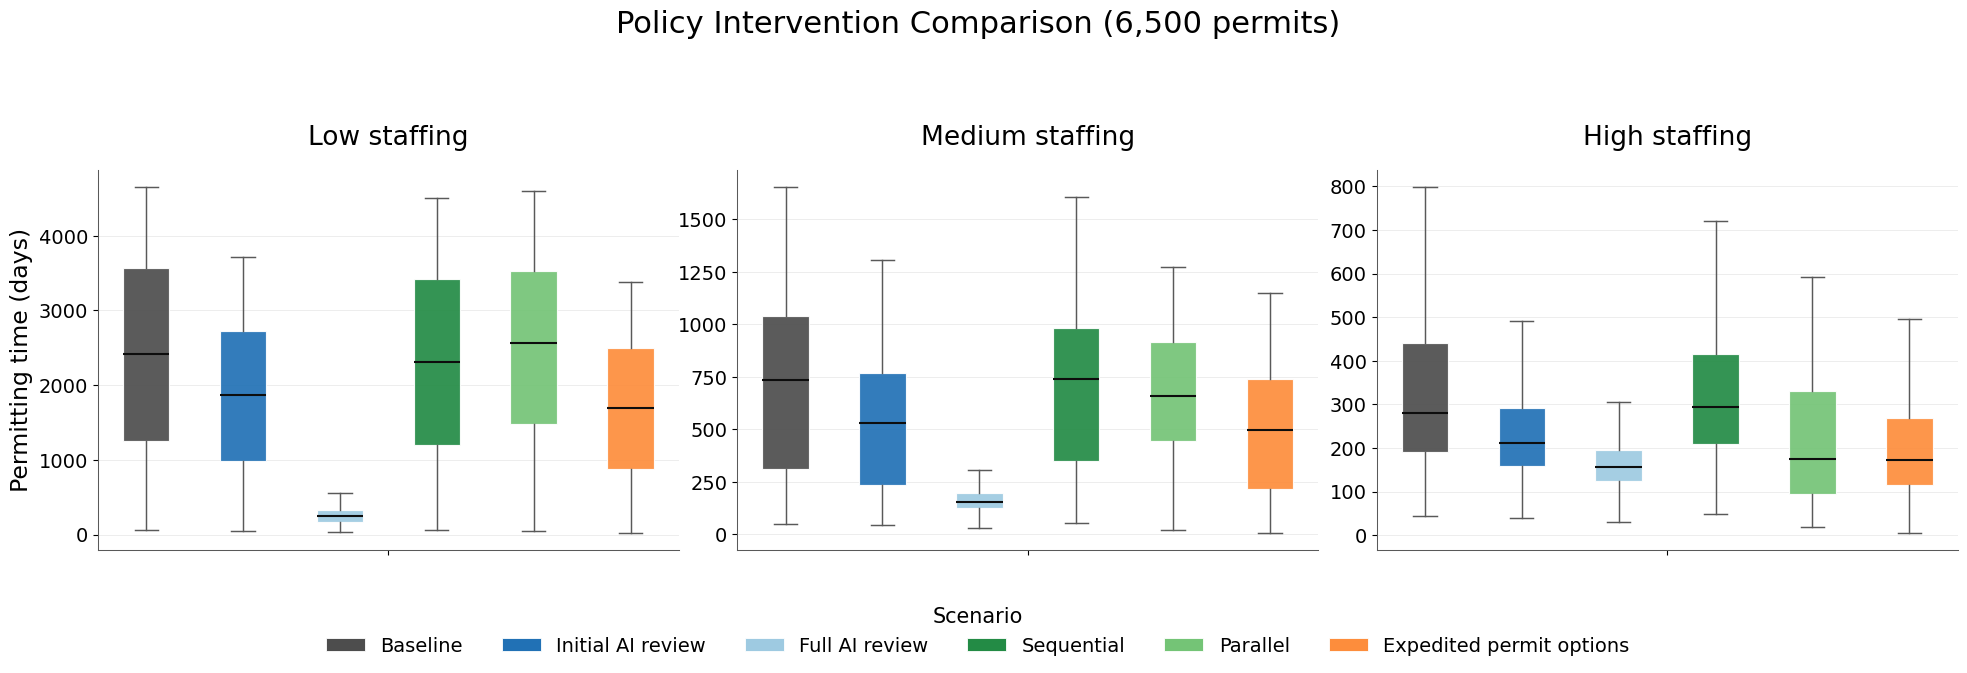

results/app_to_ready_policy_comparison_6500_permits.png


In [39]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

RESULTS_PER_RUN = Path("results") / "policy_lever_impact_per_run.csv"
if not RESULTS_PER_RUN.is_file():
    raise FileNotFoundError(
        f"Missing {RESULTS_PER_RUN}. Run the experiments cell, then the save cell, "
        "so per-run rows are written before building figures."
    )

df_run = pd.read_csv(RESULTS_PER_RUN)

required_cols = [
    "application_to_ready_run_q1_days",
    "application_to_ready_run_median_days",
    "application_to_ready_run_q3_days",
    "application_to_ready_run_whislo_days",
    "application_to_ready_run_whishi_days",
]
missing = [c for c in required_cols if c not in df_run.columns]
if missing:
    raise ValueError(
        "Missing per-run distribution columns: "
        f"{missing}. Re-run the experiments cell and save cell to regenerate policy_lever_impact_per_run.csv."
    )

POLICY_ROWS = [
    ("standard", "none", "Baseline"),
    ("standard", "initial_check", "Initial AI review"),
    ("standard", "full_review", "Full AI review"),
    ("sequential", "none", "Sequential"),
    ("parallel", "none", "Parallel"),
]
PRE_APP_LEVELS = ["lognormal_180"]

MIX_HOMOGENEOUS = "all_custom_non_like_for_like"
MIX_BALANCED = "balanced"

policy_colors = [
    "#4d4d4d",
    "#2171b5",
    "#9ecae1",
    "#238b45",
    "#74c476",
]
balanced_box_color = "#fd8d3c"

results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

permit_levels = sorted(df_run["num_permits"].unique())
staffing_levels = ["low", "medium", "high"]

n_policies = len(POLICY_ROWS)


def _mean_box_stats(sub: pd.DataFrame, cols: list[str]) -> dict[str, float]:
    mean_stats = sub[cols].apply(pd.to_numeric, errors="coerce").dropna(how="any").mean(axis=0)
    return {
        "med": float(mean_stats["application_to_ready_run_median_days"]),
        "q1": float(mean_stats["application_to_ready_run_q1_days"]),
        "q3": float(mean_stats["application_to_ready_run_q3_days"]),
        "whislo": float(mean_stats["application_to_ready_run_whislo_days"]),
        "whishi": float(mean_stats["application_to_ready_run_whishi_days"]),
    }


def _policy_intervention_comparison_table_rows(
    subset_run: pd.DataFrame,
    num_permits: int,
    staffing: str,
) -> list[dict]:
    """Same box endpoints as the Policy Intervention Comparison figures (mean of per-run quantiles)."""
    cols = [
        "application_to_ready_run_q1_days",
        "application_to_ready_run_median_days",
        "application_to_ready_run_q3_days",
        "application_to_ready_run_whislo_days",
        "application_to_ready_run_whishi_days",
    ]
    has_mix = "permit_mix" in subset_run.columns
    df_hom = (
        subset_run.loc[subset_run["permit_mix"].astype(str).eq(MIX_HOMOGENEOUS)]
        if has_mix
        else subset_run
    )
    df_bal = (
        subset_run.loc[subset_run["permit_mix"].astype(str).eq(MIX_BALANCED)]
        if has_mix
        else None
    )

    show_balanced = False
    if df_bal is not None and not df_bal.empty:
        mb = df_bal.loc[
            (df_bal["sequential"] == "standard") & (df_bal["ai_review"] == "none"),
            cols,
        ].apply(pd.to_numeric, errors="coerce")
        show_balanced = not mb.dropna(how="any").empty

    out: list[dict] = []
    mix_hom_label = MIX_HOMOGENEOUS if has_mix else "homogeneous_only"

    for pre in PRE_APP_LEVELS:
        for seq, ai, label in POLICY_ROWS:
            mask_h = (
                (df_hom["pre_application_distribution"] == pre)
                & (df_hom["sequential"] == seq)
                & (df_hom["ai_review"] == ai)
            )
            sub = df_hom.loc[mask_h, cols].apply(pd.to_numeric, errors="coerce").dropna(how="any")
            if sub.empty:
                raise ValueError(
                    f"No table rows (homogeneous): permits={num_permits}, staffing={staffing}, "
                    f"pre={pre}, sequential={seq}, ai={ai}"
                )
            ms = _mean_box_stats(sub, cols)
            out.append(
                {
                    "num_permits": num_permits,
                    "staffing_scenario": staffing,
                    "pre_application_distribution": pre,
                    "permit_mix": mix_hom_label,
                    "scenario_label": label,
                    "sequential": seq,
                    "ai_review": ai,
                    "box_q1_days": ms["q1"],
                    "box_median_days": ms["med"],
                    "box_q3_days": ms["q3"],
                    "whisker_low_days": ms["whislo"],
                    "whisker_high_days": ms["whishi"],
                }
            )
        if show_balanced:
            mask_b = (
                (df_bal["pre_application_distribution"] == pre)
                & (df_bal["sequential"] == "standard")
                & (df_bal["ai_review"] == "none")
            )
            sub_b = df_bal.loc[mask_b, cols].apply(pd.to_numeric, errors="coerce").dropna(how="any")
            if sub_b.empty:
                raise ValueError(
                    f"No table rows (balanced): permits={num_permits}, staffing={staffing}, pre={pre}"
                )
            ms_b = _mean_box_stats(sub_b, cols)
            out.append(
                {
                    "num_permits": num_permits,
                    "staffing_scenario": staffing,
                    "pre_application_distribution": pre,
                    "permit_mix": MIX_BALANCED,
                    "scenario_label": "Expedited permit options",
                    "sequential": "standard",
                    "ai_review": "none",
                    "box_q1_days": ms_b["q1"],
                    "box_median_days": ms_b["med"],
                    "box_q3_days": ms_b["q3"],
                    "whisker_low_days": ms_b["whislo"],
                    "whisker_high_days": ms_b["whishi"],
                }
            )
    return out


def _policy_group_avg_within_run_boxplots_hom_and_balanced(
    ax, subset_run: pd.DataFrame, ylabel: str
) -> None:
    """One bxp per homogeneous policy; extra bxp for balanced mix (baseline process only), same stat construction."""
    cols = [
        "application_to_ready_run_q1_days",
        "application_to_ready_run_median_days",
        "application_to_ready_run_q3_days",
        "application_to_ready_run_whislo_days",
        "application_to_ready_run_whishi_days",
    ]

    has_mix = "permit_mix" in subset_run.columns
    df_hom = (
        subset_run.loc[subset_run["permit_mix"].astype(str).eq(MIX_HOMOGENEOUS)]
        if has_mix
        else subset_run
    )
    df_bal = (
        subset_run.loc[subset_run["permit_mix"].astype(str).eq(MIX_BALANCED)]
        if has_mix
        else None
    )

    show_balanced = False
    if df_bal is not None and not df_bal.empty:
        mb = df_bal.loc[
            (df_bal["sequential"] == "standard") & (df_bal["ai_review"] == "none"),
            cols,
        ].apply(pd.to_numeric, errors="coerce")
        show_balanced = not mb.dropna(how="any").empty

    n_slots = n_policies + (1 if show_balanced else 0)
    group_stride = n_slots + 0.9
    n_groups = len(PRE_APP_LEVELS)

    stats: list[dict] = []
    positions: list[float] = []
    facecolors: list[str] = []

    for g, pre in enumerate(PRE_APP_LEVELS):
        base = g * group_stride

        for i, (seq, ai, label) in enumerate(POLICY_ROWS):
            pos = base + i
            mask_h = (
                (df_hom["pre_application_distribution"] == pre)
                & (df_hom["sequential"] == seq)
                & (df_hom["ai_review"] == ai)
            )
            sub = df_hom.loc[mask_h, cols].apply(pd.to_numeric, errors="coerce").dropna(how="any")
            if sub.empty:
                raise ValueError(
                    f"No per-run distribution rows (homogeneous mix) for pre={pre}, sequential={seq}, ai={ai}"
                )
            ms = _mean_box_stats(sub, cols)
            stats.append({**ms, "fliers": []})
            positions.append(pos)
            facecolors.append(policy_colors[i])

        if show_balanced:
            pos_b = base + n_policies
            mask_b = (
                (df_bal["pre_application_distribution"] == pre)
                & (df_bal["sequential"] == "standard")
                & (df_bal["ai_review"] == "none")
            )
            sub_b = df_bal.loc[mask_b, cols].apply(pd.to_numeric, errors="coerce").dropna(how="any")
            if sub_b.empty:
                raise ValueError(
                    f"No per-run distribution rows (balanced mix) for pre={pre}, standard, none"
                )
            ms_b = _mean_box_stats(sub_b, cols)
            stats.append({**ms_b, "fliers": []})
            positions.append(pos_b)
            facecolors.append(balanced_box_color)

    bp = ax.bxp(
        stats,
        positions=positions,
        widths=0.48,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="0.05", linewidth=1.5),
        whiskerprops=dict(color="0.35", linewidth=1.05),
        capprops=dict(color="0.35", linewidth=1.05),
    )
    for patch, fc in zip(bp["boxes"], facecolors):
        patch.set_facecolor(fc)
        patch.set_edgecolor("white")
        patch.set_linewidth(0.85)
        patch.set_alpha(0.92)

    xticks = [g * group_stride + (n_slots - 1) / 2 for g in range(n_groups)]
    ax.set_xticks(xticks)
    ax.tick_params(axis="x", labelbottom=False)
    ax.set_ylabel(ylabel, fontsize=17)
    ax.grid(axis="y", alpha=0.28, linestyle="-", linewidth=0.55)
    ax.tick_params(axis="y", labelsize=14)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


policy_intervention_graph_rows: list[dict] = []
for num_permits in permit_levels:
    for staffing in staffing_levels:
        subset_tbl = df_run[
            (df_run["num_permits"] == num_permits)
            & (df_run["staffing_scenario"] == staffing)
            & (df_run["pre_application_distribution"].isin(PRE_APP_LEVELS))
        ]
        policy_intervention_graph_rows.extend(
            _policy_intervention_comparison_table_rows(subset_tbl, num_permits, staffing)
        )

policy_intervention_graph_df = pd.DataFrame(policy_intervention_graph_rows)
policy_intervention_graph_path = results_dir / "policy_intervention_comparison_graph_table.csv"
policy_intervention_graph_df.to_csv(policy_intervention_graph_path, index=False)
print(f"Saved: {policy_intervention_graph_path}")
display(policy_intervention_graph_df)


for num_permits in permit_levels:
    plt.rcParams.update(
        {
            "figure.facecolor": "white",
            "axes.facecolor": "white",
            "axes.edgecolor": "0.35",
            "axes.linewidth": 0.75,
            "font.size": 14,
            "axes.labelsize": 16,
            "axes.titlesize": 18,
            "xtick.labelsize": 13,
            "ytick.labelsize": 13,
            "legend.fontsize": 13,
            "legend.title_fontsize": 14,
        }
    )
    fig, axes = plt.subplots(
        1,
        len(staffing_levels),
        figsize=(20, 6.8),
        sharex=True,
        sharey=False,
    )
    # Reserve upper margin so suptitle does not overlap per-panel titles / plot tops.
    fig.subplots_adjust(top=0.76, bottom=0.20, left=0.06, right=0.99, wspace=0.10)
    axes_arr = np.atleast_1d(axes)

    for c, staffing in enumerate(staffing_levels):
        ax = axes_arr[c]
        subset_run = df_run[
            (df_run["num_permits"] == num_permits)
            & (df_run["staffing_scenario"] == staffing)
            & (df_run["pre_application_distribution"].isin(PRE_APP_LEVELS))
        ]
        _policy_group_avg_within_run_boxplots_hom_and_balanced(
            ax,
            subset_run,
            "Permitting time (days)",
        )
        ax.set_title(f"{staffing.capitalize()} staffing", fontsize=19, pad=18)
        if c > 0:
            ax.set_ylabel("")

    fig.suptitle(
        f"Policy Intervention Comparison ({num_permits:,} permits)",
        fontsize=22,
        y=0.995,
    )

    handles = [
        Patch(facecolor=policy_colors[i], edgecolor="white", linewidth=0.6)
        for i in range(n_policies)
    ]
    labels = [label for _, _, label in POLICY_ROWS]
    if "permit_mix" in df_run.columns:
        handles.append(
            Patch(facecolor=balanced_box_color, edgecolor="white", linewidth=0.6)
        )
        labels.append("Expedited permit options")

    leg = fig.legend(
        handles,
        labels,
        title="Scenario",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        bbox_transform=fig.transFigure,
        ncol=6,
        fontsize=14,
        title_fontsize=15,
        frameon=False,
    )

    out_path = results_dir / f"app_to_ready_policy_comparison_{num_permits}_permits.png"
    fig.savefig(out_path, dpi=180, bbox_inches="tight", bbox_extra_artists=(leg,))
    plt.show()
    print(out_path)
